In [1]:
import numpy as np
import matplotlib.pyplot as plt
import utils.helpers as hlp
from rough1 import BayesianRegression

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from IPython.display import display, Math

# Sampling with the Wisconsin Breast Cancer data  
## Load the data

In [2]:
X, y = load_breast_cancer(return_X_y=True, as_frame=True)

## Preprocessing

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test = np.c_[np.ones((X_test.shape[0], 1)), X_test]
y_train = np.asarray(y_train, dtype=int)
y_test = np.asarray(y_test, dtype=int)

In [4]:
print(f"Training data contains {X_train.shape[0]} observations\n" 
      f"Test data contains {X_test.shape[0]} observations\n"
      f"Dimension: {X_train.shape[1]}")

Training data contains 398 observations
Test data contains 171 observations
Dimension: 31


## Set the boundary condition to select from $\ell_2$-ball prior

In [7]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(max_iter=5000)
clf.fit(X_train, y_train)
beta_hat = clf.coef_.flatten()
lp = 2 
s = 0.8 * np.linalg.norm(beta_hat, ord=lp)
display(
    Math(
        rf'\|\hat{{\beta}}\|_{lp}={np.linalg.norm(beta_hat, ord=lp):.4f}, '
        rf'\quad s={s:.4f}')
)

<IPython.core.display.Math object>

In [ ]:
# lp=2
# dim = X_train.shape[1]
# s = np.sqrt(dim)

## Sample the posterior using MySGLD algorithm

In [10]:
seed = 42
model = BayesianRegression(
    X=X_train, y=y_train, type='logistic',
    N=100, batch_size=10, lp=lp, s=s, 
    eta=5e-4, gamma=1e-3, 
    seed=seed
)
history_all, beta_mean_all = model.sample_parameters(
    method='dpsgld', iterations=500
)

  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:08<00:00, 62.19it/s]


In [11]:
history_all.shape

(501, 8, 31, 100)

In [24]:
beta_mean_all.shape

(501, 31, 100)

In [23]:
X_train.shape

(398, 31)

In [13]:
dd = history_all[0,1].T
dd[0].shape

(31,)

In [16]:
T, w, dim, N = history_all.shape

In [18]:
accuracy = []
for t in range(T):
    accuracy.append([])
for t in range(T):
    for n in range(N):
        temp = 0
        for i in range(len(X_train)):
            z = 1.0 / (
                1 + np.exp(
                    -np.dot(
                        np.transpose(history_all[t][1])[n],
                        X_train[i]
                    )
                )
            )
            if z >= 0.5:
                z = 1
            else:
                z = 0
            if y_train[i] != z:
                temp += 1
        accuracy[t].append(1 - temp/(len(X_train)))

In [19]:
result_acc = []
result_std = []
for t in range(T):
    result_acc.append(np.mean(accuracy[t]))
    result_std.append(np.std(accuracy[t]))
result_acc = np.array(result_acc)
result_std = np.array(result_std)

In [20]:
r_up = result_acc + result_std
r_down = result_acc - result_std

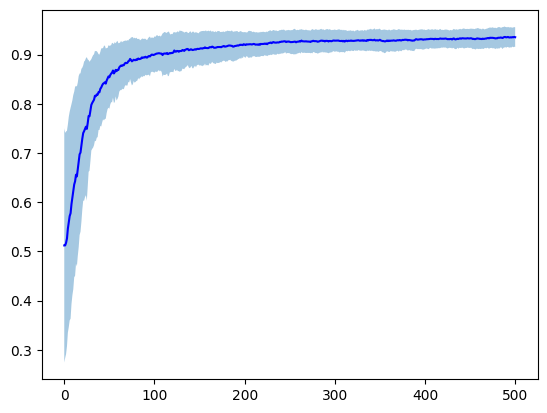

In [22]:
plt.plot(result_acc, 'b-')
plt.fill_between(range(T), r_up, r_down, alpha=0.4)

In [38]:
evaluator = AccuracyEvaluator(history_all)

In [40]:
agent = evaluator.get_selected_agent()

In [46]:
acc, std = evaluator.compute_accuracy(X_test, y_test)

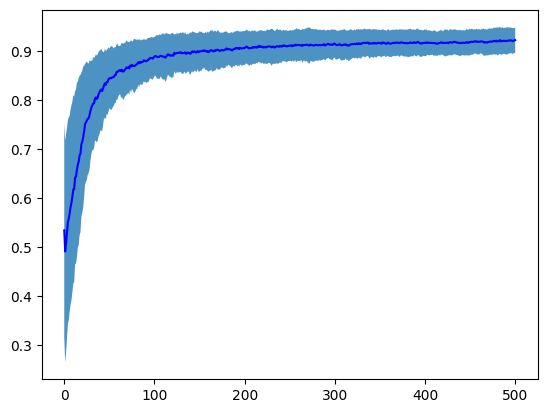

In [47]:
plt.plot(acc, 'b-')
plt.fill_between(range(len(acc)), acc-std, acc+std, alpha=0.8)

In [48]:
my_chain = model.sample_parameters(method='mysgld')

100%|██████████| 500/500 [00:00<00:00, 611.62it/s]


In [49]:
ev = AccuracyEvaluator(my_chain)

In [50]:
a,st = ev.compute_accuracy(X_test, y_test)

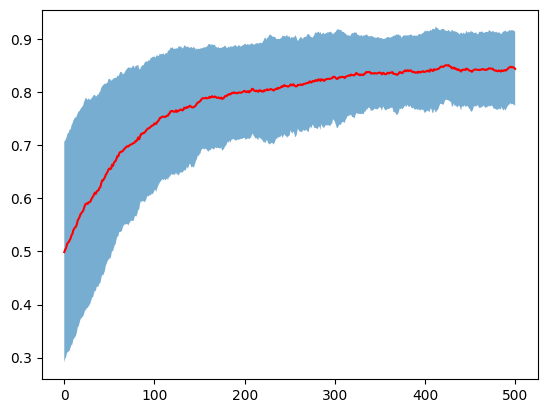

In [51]:
plt.plot(a, 'r-')
plt.fill_between(range(len(a)), a-st, a+st, alpha=0.6)